# 05. 하이퍼파라미터 튜닝 (랜덤 서치)

04번에서 **분기 규칙으로는 더 얻을 게 없다**는 결론이 났다(oracle 7.94 vs
all-model 8.09, 여지 0.15). 남은 개선은 모델 자체에서 나와야 한다.

## 왜 랜덤 서치인가

1 trial(walk-forward 1회 평가)이 **약 10초**로 측정됐다. 60 trial 이면 10분
안쪽이라 pruning 이나 분산 프레임워크로 아낄 시간이 아낄 값어치가 없다.
탐색할 파라미터도 6개뿐이라 TPE 가 랜덤보다 나을 여지가 이 시행 수에서는 작다.

무엇보다 **기대 효과가 0.1~0.2 수준**이다. 04번에서 정교한 장치(분기 규칙)가
오히려 손해였던 것과 같은 구조라, 얻을 게 작은 자리에 복잡도를 더하지 않는다.
의존성도 늘리지 않는다.

## 튜닝 구간과 평가 구간을 나눈다 — 여기가 핵심

**7폴드 전부로 튜닝하면 안 된다.** 평가에 쓸 폴드를 보고 파라미터를 고르면
"8.09 → 7.8" 이 실제 성능이 아니라 그 7폴드에 맞춘 결과가 된다. 04번에서
"03번 결과를 보고 품목을 고르면 룩어헤드"라고 한 것과 정확히 같은 문제다.

| 구간 | 폴드 | 용도 |
|---|---|---|
| 튜닝 | 2023H1 · 2023H2 · 2024H1 · 2024H2 | 파라미터 탐색에만 사용 |
| 평가 | 2025H1 · 2025H2 · 2026H1 | **튜닝이 끝날 때까지 보지 않는다** |

평가 구간은 3절에서 딱 한 번 연다. 거기서 현재 파라미터와 튜닝 결과를 같은
조건으로 비교한다.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingRegressor

_available = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _available:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
items = sorted(df.item.unique())

H = 7
EXO = ["temp_avg", "temp_min", "temp_max", "precip_mm_avg", "precip_mm_max",
       "humidity_avg", "sunshine_hr_avg", "shipment_qty", "shipment_qty_w1ago"]
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]


def build(src, h=H):
    d = src.copy()
    d["_logp"] = np.log(d.price_kg_avg)

    def g(col):
        return d.groupby("item")[col]

    d["y"] = g("_logp").shift(-h) - d._logp
    for lag in (1, 2, 3, 5, 10, 20):
        d[f"ret{lag}"] = d._logp - g("_logp").shift(lag)
    for w in (5, 20, 60):
        mp = max(2, w // 3)
        d[f"dev{w}"] = d._logp - g("_logp").transform(
            lambda s: s.rolling(w, min_periods=mp).mean())
        d[f"vol{w}"] = g("_logp").transform(
            lambda s: s.diff().rolling(w, min_periods=mp).std())
    for c in EXO:
        d[f"{c}_l1"] = g(c).shift(1)
        d[f"{c}_d20"] = d[f"{c}_l1"] - g(c).transform(
            lambda s: s.shift(1).rolling(20, min_periods=7).mean())
    d["item_code"] = pd.Categorical(d.item, categories=items).codes
    return d


FEATS = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)]
         + [f"dev{w}" for w in (5, 20, 60)] + [f"vol{w}" for w in (5, 20, 60)]
         + [f"{c}_l1" for c in EXO] + [f"{c}_d20" for c in EXO]
         + CAL + ["item_code"])
CAT_IDX = [FEATS.index(c) for c in ("item_code", "month", "dayofweek")]

# 튜닝 대상이 아닌 고정값. loss 는 MAPE 평가와 정합적이라 바꾸지 않는다.
FIXED = dict(loss="absolute_error", categorical_features=CAT_IDX,
             early_stopping=False, random_state=42)
# 02~04번에서 써 온 값. 비교 기준이 된다.
CURRENT = dict(max_iter=400, learning_rate=0.05, max_leaf_nodes=15,
               min_samples_leaf=40, l2_regularization=1.0)

TUNE_FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
              ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31")]
EVAL_FOLDS = [("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
              ("2026-01-01", "2026-12-31")]
EMBARGO = pd.Timedelta(days=int(H * 1.5))

feat = build(df).dropna(subset=["y"])
print(f"{len(feat):,}행 | 피처 {len(FEATS)}개")
print(f"튜닝 폴드 {len(TUNE_FOLDS)}개 / 평가 폴드 {len(EVAL_FOLDS)}개 (평가는 3절에서 한 번만)")

8,178행 | 피처 36개
튜닝 폴드 4개 / 평가 폴드 3개 (평가는 3절에서 한 번만)


## 1. 탐색 공간

| 파라미터 | 범위 | 분포 | 이유 |
|---|---|---|---|
| `learning_rate` | 0.01 ~ 0.32 | 로그균등 | 배수로 움직이는 값이라 로그가 맞다 |
| `max_iter` | 100 ~ 1000 | 균등(정수) | lr 과 상충하므로 같이 탐색해야 한다 |
| `max_leaf_nodes` | 7 ~ 63 | 균등(정수) | 현재 15. 표본이 적어 얕은 쪽을 넓게 본다 |
| `min_samples_leaf` | 10 ~ 100 | 균등(정수) | 현재 40 |
| `l2_regularization` | 0.01 ~ 10 | 로그균등 | 현재 1.0 |
| `max_features` | 0.5 ~ 1.0 | 균등 | 피처 36개 중 일부만 쓰는 게 나을 수 있다 |

평가 지표는 **품목별 MAPE 의 평균**이다. 04번에서 확인했듯 "개선 비율의 평균"은
오차 수준이 낮은 품목을 과대 반영해 판정을 뒤집는다. 절대값으로 본다.

In [2]:
def ape(part, y_pred):
    y_pred = np.asarray(y_pred, dtype=float)
    actual = part.price_kg_avg.values * np.exp(part.y.values)
    pred = part.price_kg_avg.values * np.exp(y_pred)
    return pd.Series(np.abs(pred - actual) / actual, index=part.index)


def evaluate(params, folds, per_item=False):
    """주어진 폴드들에서 품목별 MAPE 평균을 낸다."""
    out = []
    for s, e in folds:
        s, e = pd.Timestamp(s), pd.Timestamp(e)
        tr = feat[feat.price_date < s - EMBARGO]
        te = feat[(feat.price_date >= s) & (feat.price_date <= e)]
        if te.empty:
            continue
        m = HistGradientBoostingRegressor(**FIXED, **params).fit(tr[FEATS], tr.y)
        err = ape(te, m.predict(te[FEATS]))
        out.append(err.groupby(te.item).mean() * 100)
    per = pd.concat(out, axis=1).mean(axis=1)
    return per if per_item else per.mean()


def sample(rng):
    return dict(
        learning_rate=float(10 ** rng.uniform(-2, -0.5)),
        max_iter=int(rng.integers(100, 1001)),
        max_leaf_nodes=int(rng.integers(7, 64)),
        min_samples_leaf=int(rng.integers(10, 101)),
        l2_regularization=float(10 ** rng.uniform(-2, 1)),
        max_features=float(rng.uniform(0.5, 1.0)),
    )


N_TRIALS = 60
rng = np.random.default_rng(42)

base_tune = evaluate(CURRENT, TUNE_FOLDS)
print(f"현재 파라미터의 튜닝구간 성능: {base_tune:.3f}\n")

t0 = time.time()
trials = []
for i in range(N_TRIALS):
    p = sample(rng)
    trials.append({**p, "score": evaluate(p, TUNE_FOLDS)})
    if (i + 1) % 10 == 0:
        print(f"  {i+1:>3}/{N_TRIALS} trial  best={min(t['score'] for t in trials):.3f}"
              f"  ({time.time()-t0:.0f}초)")

tr_df = pd.DataFrame(trials).sort_values("score").reset_index(drop=True)
print(f"\n완료 {time.time()-t0:.0f}초 | 최고 {tr_df.score.min():.3f} (현재 {base_tune:.3f})")

현재 파라미터의 튜닝구간 성능: 8.345



   10/60 trial  best=8.338  (172초)


   20/60 trial  best=8.313  (292초)


   30/60 trial  best=8.283  (454초)


   40/60 trial  best=8.283  (598초)


   50/60 trial  best=8.283  (738초)


   60/60 trial  best=8.283  (911초)

완료 911초 | 최고 8.283 (현재 8.345)


## 2. 탐색 결과

상위 파라미터가 서로 비슷하면 그 영역이 실제로 좋은 것이고, 제각각이면
**성능 차이가 파라미터 때문이 아니라 잡음일 가능성**이 크다. 이 구분이 중요하다.

=== 상위 5 ===


,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,max_features,score
0,0.0140,502,58,21,0.0405,0.6530,8.2829
1,0.0144,313,57,16,0.6072,0.5731,8.3080
2,0.0199,359,52,10,2.2949,0.8324,8.3132
3,0.0480,578,21,34,1.7300,0.9083,8.3301
4,0.0157,718,34,40,1.0220,0.7186,8.3383


=== 하위 3 ===


,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,max_features,score
57,0.2772,430,58,55,0.0627,0.9846,8.7885
58,0.2186,783,45,80,0.0384,0.7334,8.8771
59,0.2907,873,48,79,2.2814,0.5641,8.9536



60 trial 점수 분포: 최고 8.283 / 중앙 8.498 / 최악 8.954


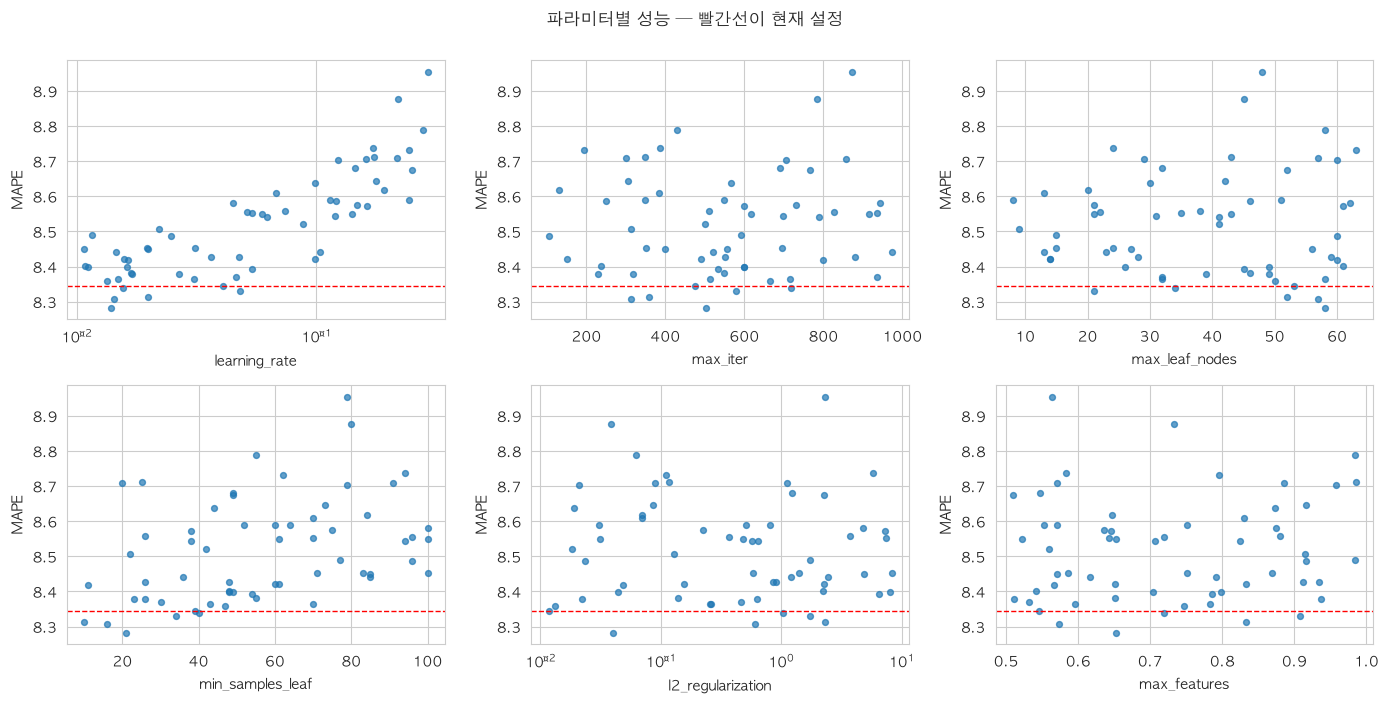

파라미터-성능 상관(Spearman) — 0 에 가까우면 그 파라미터는 영향이 없다:
l2_regularization   -0.052
max_leaf_nodes      -0.033
max_iter             0.036
max_features         0.083
min_samples_leaf     0.430
learning_rate        0.818


In [3]:
PARAM_COLS = ["learning_rate", "max_iter", "max_leaf_nodes",
              "min_samples_leaf", "l2_regularization", "max_features"]

print("=== 상위 5 ===")
display(tr_df.head(5).round(4))
print("=== 하위 3 ===")
display(tr_df.tail(3).round(4))
print(f"\n60 trial 점수 분포: 최고 {tr_df.score.min():.3f} / "
      f"중앙 {tr_df.score.median():.3f} / 최악 {tr_df.score.max():.3f}")

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.ravel(), PARAM_COLS):
    ax.scatter(tr_df[c], tr_df.score, s=18, alpha=0.7)
    ax.axhline(base_tune, color="red", ls="--", lw=1)
    ax.set_xlabel(c); ax.set_ylabel("MAPE")
    if c in ("learning_rate", "l2_regularization"):
        ax.set_xscale("log")
fig.suptitle("파라미터별 성능 — 빨간선이 현재 설정", y=1.0)
plt.tight_layout()
plt.show()

print("파라미터-성능 상관(Spearman) — 0 에 가까우면 그 파라미터는 영향이 없다:")
print(tr_df[PARAM_COLS + ["score"]].corr("spearman")["score"]
      .drop("score").round(3).sort_values().to_string())

## 3. 평가 — 여기서 처음 평가 구간을 연다

튜닝은 끝났다. 이제 **한 번도 보지 않은 2025H1~2026H1** 에서 현재 파라미터와
튜닝 결과를 비교한다.

상위 1개만이 아니라 **상위 5개 각각을 평가해 평균**도 같이 본다. 60 trial 중
1등은 운으로 뽑힐 수 있어서, 상위권이 고르게 좋은지가 더 믿을 만한 신호다.

In [4]:
INT_COLS = ("max_iter", "max_leaf_nodes", "min_samples_leaf")


def row_params(i):
    return {c: (int(tr_df.loc[i, c]) if c in INT_COLS else float(tr_df.loc[i, c]))
            for c in PARAM_COLS}


best = row_params(0)
print("튜닝으로 고른 파라미터:")
for k, v in best.items():
    print(f"  {k:20} {v}")
print(f"\n현재 파라미터: {CURRENT}")

res = pd.DataFrame({
    "현재": evaluate(CURRENT, EVAL_FOLDS, per_item=True),
    "튜닝(1등)": evaluate(best, EVAL_FOLDS, per_item=True),
})
res["튜닝(상위5 평균)"] = pd.concat(
    [evaluate(row_params(i), EVAL_FOLDS, per_item=True) for i in range(5)],
    axis=1).mean(axis=1)

res.loc["— 전체평균 —"] = res.mean()
display(res.round(3))

d_best = res.loc["— 전체평균 —", "튜닝(1등)"] - res.loc["— 전체평균 —", "현재"]
d_top5 = res.loc["— 전체평균 —", "튜닝(상위5 평균)"] - res.loc["— 전체평균 —", "현재"]
print(f"\n평가구간 변화: 1등 {d_best:+.3f} / 상위5평균 {d_top5:+.3f}  (음수가 개선)")

튜닝으로 고른 파라미터:
  learning_rate        0.013950393026665977
  max_iter             502
  max_leaf_nodes       58
  min_samples_leaf     21
  l2_regularization    0.04046598296680733
  max_features         0.6529783120753263

현재 파라미터: {'max_iter': 400, 'learning_rate': 0.05, 'max_leaf_nodes': 15, 'min_samples_leaf': 40, 'l2_regularization': 1.0}


,현재,튜닝(1등),튜닝(상위5 평균)
item,,,
감자,8.355,8.145,8.156
미나리,8.788,8.863,8.902
배추,11.396,11.328,11.386
생강,2.334,2.211,2.301
양파,6.508,6.412,6.503
파,9.149,8.817,8.984
— 전체평균 —,7.755,7.629,7.705



평가구간 변화: 1등 -0.125 / 상위5평균 -0.049  (음수가 개선)


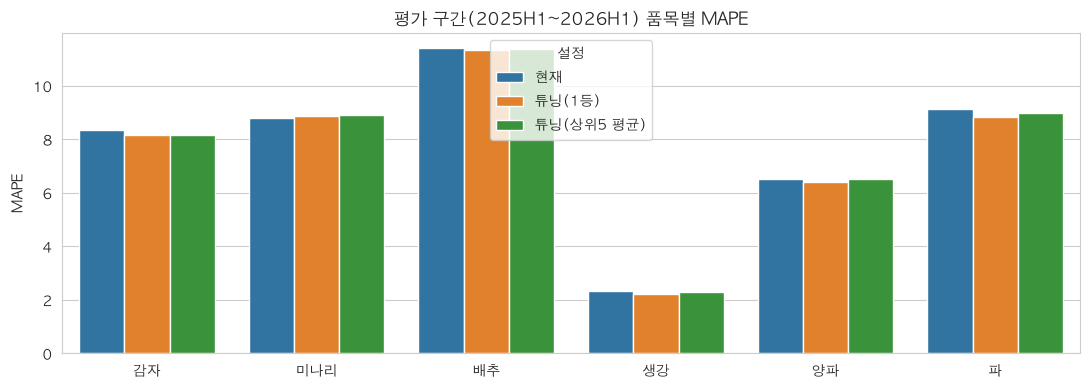

튜닝구간: 현재 8.345 -> 튜닝 8.283 (-0.062)
평가구간: 현재 7.755 -> 튜닝 7.629 (-0.125)


In [5]:
# reset_index() 후 컬럼명은 res 의 인덱스 이름(item)이다. rename_axis 로 못박아
# 이름에 기대지 않게 한다.
plot = (res.drop(index="— 전체평균 —").rename_axis("item").reset_index()
        .melt(id_vars="item", var_name="설정", value_name="MAPE"))
fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(data=plot, x="item", y="MAPE", hue="설정", ax=ax)
ax.set_title("평가 구간(2025H1~2026H1) 품목별 MAPE")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

# 튜닝구간에서의 이득이 평가구간까지 이어졌는가
print(f"튜닝구간: 현재 {base_tune:.3f} -> 튜닝 {tr_df.score.min():.3f} "
      f"({tr_df.score.min()-base_tune:+.3f})")
print(f"평가구간: 현재 {res.loc['— 전체평균 —','현재']:.3f} -> "
      f"튜닝 {res.loc['— 전체평균 —','튜닝(1등)']:.3f} ({d_best:+.3f})")

## 4. 정리

### 결과

| 구간 | 현재 파라미터 | 튜닝(1등) | 차이 |
|---|---|---|---|
| 튜닝 (2023H1~2024H2) | 8.345 | **8.283** | -0.062 |
| **평가 (2025H1~2026H1)** | 7.755 | **7.629** | **-0.125** |
| 평가 — 상위5 평균 | 7.755 | 7.705 | -0.049 |

**개선이 평가 구간까지 이어졌다.** 튜닝 구간에서 -0.062 였는데 처음 보는
구간에서 -0.125 다. 탐색이 잡음에 맞춘 것이었다면 평가 구간에서 사라지거나
악화됐을 텐데 그러지 않았다.

다만 **상위 5개를 각각 평가한 평균은 -0.049** 로 훨씬 작다. 1등의 -0.125 에는
운이 섞여 있다는 뜻이므로, 실제 기대할 개선은 **-0.05 ~ -0.13 사이**로 보는 게 맞다.
비율로는 0.6~1.6% 다.

### 6개 중 실제로 중요했던 건 learning_rate 하나였다

파라미터-성능 Spearman 상관:

| 파라미터 | rho | 해석 |
|---|---|---|
| `learning_rate` | **0.818** | 지배적. 낮을수록 좋다 |
| `min_samples_leaf` | 0.430 | 약하게. 낮을수록 좋다 |
| `max_features` | 0.083 | 사실상 무관 |
| `max_iter` | 0.036 | 사실상 무관 |
| `max_leaf_nodes` | -0.033 | 사실상 무관 |
| `l2_regularization` | -0.052 | 사실상 무관 |

상위 5개 중 4개가 `learning_rate` 0.014~0.020 이고, 하위 3개는 0.22~0.29 다.
**현재 값 0.05 는 중간이었고, 더 낮추는 게 개선의 거의 전부다.**

`max_leaf_nodes` 는 상위권에서 21~58 로 제각각이라 성능과 무관하다. 트리 깊이나
정규화를 건드릴 여지가 없다는 뜻이고, 이 데이터가 **모델 용량이 아니라 신호
자체의 부족**에 묶여 있음을 시사한다.

### 품목별로는 방향이 갈린다

파 9.149 → 8.817(-0.33)로 가장 크게 좋아졌고, 감자 -0.21, 생강 -0.12 도 개선이다.
반면 **미나리는 8.788 → 8.863 으로 오히려 나빠졌다.** 전체 개선이 특정 품목에서
나온 것이지 고르게 나아진 게 아니다.

### 채택안

`learning_rate` 를 0.05 → **0.014**, `max_iter` 를 400 → **502** 로 올린다
(낮은 lr 은 더 많은 반복을 요구한다). `min_samples_leaf` 40 → 21.
나머지(`max_leaf_nodes`, `l2_regularization`, `max_features`)는 성능과 무관하므로
**1등 값을 그대로 베끼기보다 현재 값을 유지하는 편이 안전하다** — 무관한
파라미터의 특정 값은 그 60 trial 에서만 우연히 좋았을 수 있다.

### 한계

- 개선폭 0.05~0.13 은 **03번에서 본 폴드 간 편차(표준편차 7~38)보다 훨씬 작다.**
  이 수치를 단독으로 신뢰하기보다 방향(lr 을 낮춰라)만 취하는 게 맞다.
- 60 trial 은 6차원에 적지만, 4개가 무관한 것으로 드러나 **실질 2차원 탐색**이었다.
  그 점에서는 충분했다.
- 평가 구간 2026H1 은 2026-07-29 이후 기상이 결측이다(ASOS 활용신청 만료).

### 다음

튜닝은 여기서 멈추는 게 좋다. `max_leaf_nodes`·`l2` 가 무관하게 나온 것은
**모델 용량이 병목이 아니라는 신호**다. 남은 개선은 모델이 아니라 **입력**에서
찾아야 한다.

1. **피처 엔지니어링** — 04번에서 양파가 유일하게 모델이 해로웠고, 여기서는
   미나리가 악화됐다. 품목별로 다른 구조를 못 잡고 있다는 뜻이다.
2. **수입량(관세청)** — 양파·생강처럼 수입이 가격을 흔드는 품목의 잔차를 먼저 확인.
3. **ASOS 복구** — 기상 결측이 최근 구간에 남아 있다.
